# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 1 — Constant-amplitude cyclic loading and S–N curve

- [Exercise 1.1](#ex1) — Characterisation of a general constant-amplitude cycle
- [Exercise 1.2](#ex2) — Pulsating constant-amplitude loading
- [Exercise 1.3](#ex3) — Fully reversed constant-amplitude loading
- [Exercise 1.4](#ex4) — General relations between cyclic stress parameters
- [Exercise 1.5](#ex5) — S–N curve of a structural steel (Basquin law)
- [Exercise 1.6](#ex6) — Conceptual questions on fatigue fundamentals


In [1]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from IPython.display import Latex, Markdown, display
from typing import NamedTuple

# --- Plotting defaults (academic style) ---
FS = 14
plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})

# Reusable colour palette (consistent across all exercises)
COLORS = {
    'sigma':   '#1f4e79',   # signal
    'sig_max': '#c0392b',
    'sig_min': '#c0392b',
    'sig_m':   '#27ae60',
    'sig_a':   '#8e44ad',
    'curve':   '#1f4e79',
    'point':   '#c0392b',
    'guide':   '0.55',
}


---

## Formulary — Constant-amplitude cyclic loading

| Parameter | Symbol | Formula |
|:----------|:------:|:--------|
| Maximum stress | $\sigma_{\max}$ | given |
| Minimum stress | $\sigma_{\min}$ | given |
| Mean stress | $\sigma_m$ | $\sigma_m = (\sigma_{\max}+\sigma_{\min})/2$ |
| Stress amplitude | $\sigma_a$ | $\sigma_a = (\sigma_{\max}-\sigma_{\min})/2$ |
| Stress range | $\Delta\sigma$ | $\Delta\sigma = \sigma_{\max}-\sigma_{\min} = 2\,\sigma_a$ |
| Stress ratio | $R$ | $R = \sigma_{\min}/\sigma_{\max}$ |
| Amplitude ratio | $A$ | $A = \sigma_a/\sigma_m = (1-R)/(1+R)$ |

**S–N power-law form:** $\;\Delta\sigma^{\,m}\,N_f = C\,$ (constant)

**Basquin relation:** $\;\dfrac{\Delta\sigma}{2} = \sigma_a = \sigma_f'\,(2N_f)^{b}\,$
with $\sigma_f'$ the fatigue strength coefficient and $b$ the fatigue strength exponent.

#### Tabela de equivalência terminológica (inglês $\leftrightarrow$ português)

| Inglês           | Português recomendado                        | Símbolo         |
| ---------------- | -------------------------------------------- |-----------------|
| Maximum stress   | tensão máxima                                | $\sigma_{\max}$ |
| Minimum stress   | tensão mínima                                | $\sigma_{\min}$ |
| Mean stress      | tensão média                                 | $\sigma_m$      |
| Stress amplitude | amplitude de tensão                          | $\sigma_a$      |
| Stress range     | gama de tensão (variação de tensão)          | $\Delta\sigma$  |
| Stress ratio     | razão de tensões                             | $R$              |
| Amplitude ratio  | razão de amplitude                           | $A$              |


### Helper functions

The function `cyclic_params` returns the full set of derived parameters from any
$(\sigma_{\max},\sigma_{\min})$ pair, and `plot_stress_signal` draws the
sinusoidal stress history with all relevant levels annotated. They are used in
every exercise below.


In [2]:
def cyclic_params(sigma_max, sigma_min):
    '''Return σ_m, σ_a, Δσ, R, A from (σ_max, σ_min).'''
    sigma_m     = (sigma_max + sigma_min) / 2
    sigma_a     = (sigma_max - sigma_min) / 2
    delta_sigma =  sigma_max - sigma_min
    R = sigma_min / sigma_max if sigma_max != 0 else None
    A = sigma_a   / sigma_m   if sigma_m   != 0 else np.inf
    return dict(sigma_max=sigma_max, sigma_min=sigma_min,
                sigma_m=sigma_m, sigma_a=sigma_a,
                delta_sigma=delta_sigma, R=R, A=A)

def print_params(p, title=''):
    if title:
        print('═'*64); print(' ', title); print('═'*64)
    print(f'  σ_max  = {p["sigma_max"]:+8.2f} MPa')
    print(f'  σ_min  = {p["sigma_min"]:+8.2f} MPa')
    print(f'  σ_m    = {p["sigma_m"]:+8.2f} MPa')
    print(f'  σ_a    = {p["sigma_a"]:8.2f} MPa')
    print(f'  Δσ     = {p["delta_sigma"]:8.2f} MPa')
    if p['R'] is None:
        print(f'  R      =     n/a (σ_max = 0)')
    else:
        print(f'  R      = {p["R"]:8.4f}')
    if p['A'] == np.inf:
        print(f'  A      =       ∞')
    else:
        print(f'  A      = {p["A"]:8.4f}')

def plot_stress_signal(p, title='', n_cycles=3, ax=None):
    '''Plot the sinusoidal stress signal with σ_max, σ_min, σ_m and σ_a annotated.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    t     = np.linspace(0, n_cycles, 600)
    sigma = p['sigma_m'] + p['sigma_a'] * np.sin(2*np.pi*t)
    ax.plot(t, sigma, color=COLORS['sigma'], lw=2.2, label=r'$\sigma(t)$')
    ax.axhline(p['sigma_max'], color=COLORS['sig_max'], ls='--', alpha=0.7,
               label=rf'$\sigma_{{\max}}={p["sigma_max"]:+.0f}$ MPa')
    ax.axhline(p['sigma_min'], color=COLORS['sig_min'], ls='--', alpha=0.7,
               label=rf'$\sigma_{{\min}}={p["sigma_min"]:+.0f}$ MPa')
    ax.axhline(p['sigma_m'],   color=COLORS['sig_m'],   ls='-.', alpha=0.8,
               label=rf'$\sigma_m={p["sigma_m"]:+.0f}$ MPa')
    ax.axhline(0, color='k', lw=0.5)
    # annotate σ_a
    t_ann = 0.25
    ax.annotate('', xy=(t_ann+0.05, p['sigma_max']),
                xytext=(t_ann+0.05, p['sigma_m']),
                arrowprops=dict(arrowstyle='<->', color=COLORS['sig_a'], lw=1.5))
    ax.text(t_ann+0.15, p['sigma_m']+p['sigma_a']/2,
            rf'$\sigma_a={p["sigma_a"]:.0f}$ MPa',
            color=COLORS['sig_a'], va='center')
    ax.set_xlabel('Time / Period'); ax.set_ylabel('Stress (MPa)')
    if title: ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.set_xlim(0, n_cycles)
    margin = max(abs(p['sigma_max']), abs(p['sigma_min']))*0.35
    ax.set_ylim(p['sigma_min']-margin, p['sigma_max']+margin)
    plt.tight_layout()


<a id='ex1'></a>
---

## Exercise 1.1 — Characterisation of a general constant-amplitude cycle

Consider the constant-amplitude cyclic loading depicted in the figure below,
characterised by a sinusoidal stress waveform. The loading has the potential to
induce fatigue damage in a given material if applied for a sufficient number of
cycles, **even though the maximum stress remains below the static strength of
the material** (e.g. below the yield stress). Only one cycle ($N=1$) is shown
in the LaTeX figure (reproduced numerically below).

From the graph, the following values can be read:

\begin{equation*}
\sigma_{\max} = 150~\text{MPa},\qquad \sigma_{\min} = -50~\text{MPa}.
\tag{1.1}\end{equation*}

(a) Compute the mean stress $\sigma_m$.

(b) Compute the stress amplitude $\sigma_a$.

(c) Compute the stress range $\Delta\sigma$.

(d) Compute the stress ratio $R$.

(e) Compute the amplitude ratio $A$ and verify $A=(1-R)/(1+R)$.

(f) Classify the loading (pulsating $R=0$, fully reversed $R=-1$, or general $R\neq 0,-1$).

> **Remark.** Only **two** independent parameters from
> $\{\sigma_{\max},\,\sigma_{\min},\,\sigma_m,\,\sigma_a,\,\Delta\sigma,\,R\}$
> are needed to fully define the cycle. The pair $(R,A)$ on its own is
> insufficient, because $A$ is a function of $R$ alone.

### Solution


#### (a) Mean stress

By definition (formulary, top of notebook),

\begin{equation*}
\sigma_m = \dfrac{\sigma_{\max}+\sigma_{\min}}{2}
        = \dfrac{150 + (-50)}{2} = 50~\text{MPa}.
\tag{1.2}\end{equation*}


In [3]:
sigma_max, sigma_min = 150.0, -50.0   # MPa  (data of Ex. 1.1)
p1 = cyclic_params(sigma_max, sigma_min)

print(f'(a) σ_m = (σ_max + σ_min)/2 = ({sigma_max} + ({sigma_min}))/2 = {p1["sigma_m"]:.1f} MPa')


(a) σ_m = (σ_max + σ_min)/2 = (150.0 + (-50.0))/2 = 50.0 MPa


#### (b) Stress amplitude

\begin{equation*}
\sigma_a = \dfrac{\sigma_{\max}-\sigma_{\min}}{2}
        = \dfrac{150 - (-50)}{2} = 100~\text{MPa}.
\tag{1.3}\end{equation*}


In [4]:
print(f'(b) σ_a = (σ_max − σ_min)/2 = ({sigma_max} − ({sigma_min}))/2 = {p1["sigma_a"]:.1f} MPa')


(b) σ_a = (σ_max − σ_min)/2 = (150.0 − (-50.0))/2 = 100.0 MPa


#### (c) Stress range

\begin{equation*}
\Delta\sigma = \sigma_{\max}-\sigma_{\min} = 2\,\sigma_a
            = 200~\text{MPa}.
\tag{1.4}\end{equation*}


In [5]:
print(f'(c) Δσ = σ_max − σ_min = 2·σ_a = {p1["delta_sigma"]:.1f} MPa')


(c) Δσ = σ_max − σ_min = 2·σ_a = 200.0 MPa


#### (d) Stress ratio

\begin{equation*}
R = \dfrac{\sigma_{\min}}{\sigma_{\max}}
  = \dfrac{-50}{150} = -\dfrac{1}{3} \approx -0.333.
\tag{1.5}\end{equation*}


In [6]:
print(f'(d) R = σ_min/σ_max = ({sigma_min})/({sigma_max}) = {p1["R"]:+.4f}  (≈ −1/3)')


(d) R = σ_min/σ_max = (-50.0)/(150.0) = -0.3333  (≈ −1/3)


#### (e) Amplitude ratio and verification of $A=(1-R)/(1+R)$

\begin{equation*}
A = \dfrac{\sigma_a}{\sigma_m} = \dfrac{100}{50} = 2.
\tag{1.6}\end{equation*}

Using the identity,

\begin{equation*}
A = \dfrac{1-R}{1+R}
  = \dfrac{1-(-1/3)}{1+(-1/3)}
  = \dfrac{4/3}{2/3} = 2.\;\checkmark
\tag{1.7}\end{equation*}


In [7]:
A_direct   = p1['sigma_a'] / p1['sigma_m']
A_from_R   = (1 - p1['R']) / (1 + p1['R'])
print(f'(e) A = σ_a/σ_m       = {A_direct:.4f}')
print(f'    A = (1−R)/(1+R)   = {A_from_R:.4f}')
print(f'    Difference        = {abs(A_direct - A_from_R):.2e}   (≈ 0  ⇒ identity verified)')


(e) A = σ_a/σ_m       = 2.0000
    A = (1−R)/(1+R)   = 2.0000
    Difference        = 2.22e-16   (≈ 0  ⇒ identity verified)


#### (f) Classification

Because $R=-1/3$ is **neither** $0$ (pulsating) **nor** $-1$ (fully reversed),
the loading is a **general constant-amplitude cycle**. The stress oscillates
about a positive mean ($\sigma_m>0$) and crosses zero in compression
($\sigma_{\min}<0$).


(f) Classification of the cycle:
    R = -0.3333  ⇒  general cycle (R ≠ 0 and R ≠ −1)
    σ_m = +50.0 MPa > 0   (positive mean)
    σ_min = -50.0 MPa < 0  (compression-tension cycle)
════════════════════════════════════════════════════════════════
  Summary of Exercise 1.1
════════════════════════════════════════════════════════════════
  σ_max  =  +150.00 MPa
  σ_min  =   -50.00 MPa
  σ_m    =   +50.00 MPa
  σ_a    =   100.00 MPa
  Δσ     =   200.00 MPa
  R      =  -0.3333
  A      =   2.0000


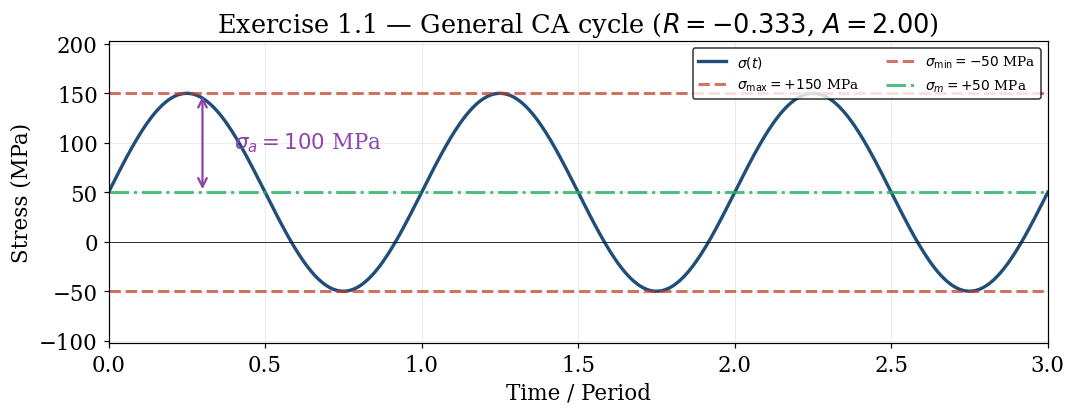

In [8]:
print('(f) Classification of the cycle:')
print(f'    R = {p1["R"]:+.4f}  ⇒  general cycle (R ≠ 0 and R ≠ −1)')
print(f'    σ_m = {p1["sigma_m"]:+.1f} MPa > 0   (positive mean)')
print(f'    σ_min = {p1["sigma_min"]:+.1f} MPa < 0  (compression-tension cycle)')

print_params(p1, 'Summary of Exercise 1.1')
plot_stress_signal(p1, title='Exercise 1.1 — General CA cycle '
                   rf'($R={p1["R"]:+.3f}$, $A={p1["A"]:.2f}$)')
plt.show()


#### Solution summary — Exercise 1.1

| Part | Quantity         | Formula                                | Value |
|:----:|:-----------------|:---------------------------------------|------:|
| (a)  | $\sigma_m$       | $(\sigma_{\max}+\sigma_{\min})/2$      | $50$ MPa |
| (b)  | $\sigma_a$       | $(\sigma_{\max}-\sigma_{\min})/2$      | $100$ MPa |
| (c)  | $\Delta\sigma$  | $\sigma_{\max}-\sigma_{\min}$         | $200$ MPa |
| (d)  | $R$              | $\sigma_{\min}/\sigma_{\max}$         | $-1/3$ |
| (e)  | $A$              | $(1-R)/(1+R)$                         | $2$ |
| (f)  | Classification   | $R\neq 0,-1$                          | general cycle |


<a id='ex2'></a>
---

## Exercise 1.2 — Pulsating constant-amplitude loading

Consider the constant-amplitude **pulsating** loading. From the graph, the
following peak values can be read:

\begin{equation*}
\sigma_{\max} = 200~\text{MPa},\qquad \sigma_{\min} = 0~\text{MPa}.
\tag{2.1}\end{equation*}


(a) Compute all cyclic stress parameters: $\sigma_m$, $\sigma_a$, $\Delta\sigma$, $R$, $A$.

(b) Verify that for pulsating loading: $R=0$, $A=1$, $\sigma_a=\sigma_m$,
    and $\Delta\sigma=\sigma_{\max}$.

### Solution


#### (a) Cyclic stress parameters

Applying the definitions with $\sigma_{\min}=0$:

\begin{equation*}
\sigma_m = \dfrac{\sigma_{\max}+0}{2} = \dfrac{\sigma_{\max}}{2} = 100~\text{MPa},\qquad
\sigma_a = \dfrac{\sigma_{\max}-0}{2} = \dfrac{\sigma_{\max}}{2} = 100~\text{MPa},
\tag{2.2}\end{equation*}

\begin{equation*}
\Delta\sigma = \sigma_{\max}-0 = 200~\text{MPa},\quad
R = 0/\sigma_{\max} = 0,\quad
A = \dfrac{\sigma_a}{\sigma_m} = 1.
\tag{2.3}\end{equation*}


In [9]:
p2 = cyclic_params(sigma_max=200.0, sigma_min=0.0)
print_params(p2, 'Exercise 1.2 — Pulsating CA loading')


════════════════════════════════════════════════════════════════
  Exercise 1.2 — Pulsating CA loading
════════════════════════════════════════════════════════════════
  σ_max  =  +200.00 MPa
  σ_min  =    +0.00 MPa
  σ_m    =  +100.00 MPa
  σ_a    =   100.00 MPa
  Δσ     =   200.00 MPa
  R      =   0.0000
  A      =   1.0000


#### (b) Verification of pulsating-cycle properties

| Property                         | Predicted | Computed                | Pass |
|:---------------------------------|:---------:|:-----------------------:|:----:|
| $R = 0$                          | $0$       | $R = 0$                 | ✓ |
| $A = 1$                          | $1$       | $A = 1$                 | ✓ |
| $\sigma_a = \sigma_m$          | equal     | $100 = 100$ MPa         | ✓ |
| $\Delta\sigma = \sigma_{\max}$| equal     | $200 = 200$ MPa         | ✓ |


  R = 0                          → ✓
  A = 1                          → ✓
  σ_a = σ_m                      → ✓
  Δσ = σ_max                     → ✓


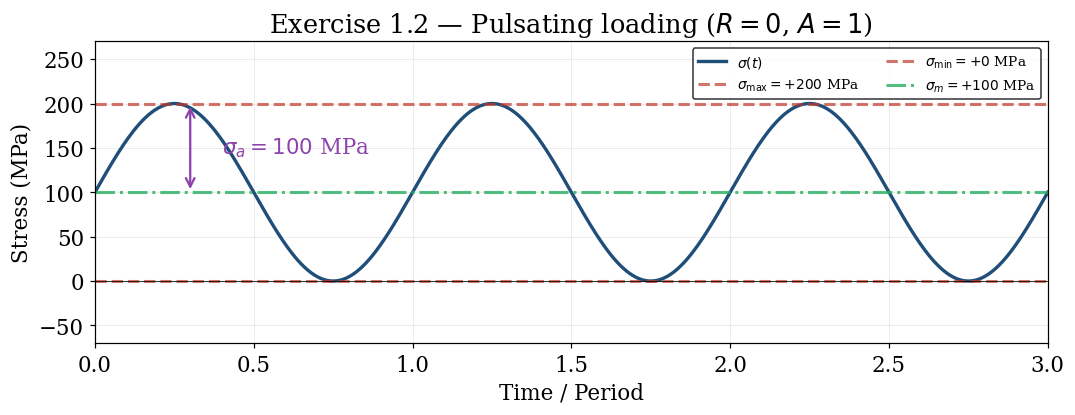

In [10]:
checks = [
    ('R = 0',                  np.isclose(p2['R'], 0.0)),
    ('A = 1',                  np.isclose(p2['A'], 1.0)),
    ('σ_a = σ_m',              np.isclose(p2['sigma_a'], p2['sigma_m'])),
    ('Δσ = σ_max',             np.isclose(p2['delta_sigma'], p2['sigma_max'])),
]
for name, ok in checks:
    print(f'  {name:30s} → {"✓" if ok else "✗"}')

plot_stress_signal(p2, title='Exercise 1.2 — Pulsating loading ($R=0$, $A=1$)')
plt.show()


<a id='ex3'></a>
---

## Exercise 1.3 — Fully reversed (alternating) constant-amplitude loading

From the graph, the following peak values can be read:

\begin{equation*}
\sigma_{\max} = 200~\text{MPa},\qquad \sigma_{\min} = -200~\text{MPa}.
\tag{3.1}\end{equation*}

(a) Compute all cyclic stress parameters.

(b) Verify $R=-1$, $\sigma_m=0$, $\sigma_a=\sigma_{\max}$.

(c) Show that $A\to\infty$ when $R\to-1$, and explain why $(\sigma_m,R)$
    with $R=-1$ is insufficient to define the loading uniquely.

### Solution


#### (a)–(b) Parameters and verification

With $\sigma_{\max}=-\sigma_{\min}=200$ MPa:

\begin{equation*}
\sigma_m = \dfrac{200 + (-200)}{2} = 0,\qquad
\sigma_a = \dfrac{200 - (-200)}{2} = 200~\text{MPa},
\tag{3.2}\end{equation*}

\begin{equation*}
\Delta\sigma = 400~\text{MPa},\qquad R = -1,\qquad
A = \dfrac{\sigma_a}{\sigma_m} = \dfrac{200}{0} \to \infty.
\tag{3.3}\end{equation*}


In [11]:
p3 = cyclic_params(sigma_max=200.0, sigma_min=-200.0)
print_params(p3, 'Exercise 1.3 — Fully reversed CA loading')

checks = [
    ('R = −1',          np.isclose(p3['R'], -1.0)),
    ('σ_m = 0',         np.isclose(p3['sigma_m'], 0.0)),
    ('σ_a = σ_max',     np.isclose(p3['sigma_a'], p3['sigma_max'])),
]
for name, ok in checks:
    print(f'  {name:30s} → {"✓" if ok else "✗"}')


════════════════════════════════════════════════════════════════
  Exercise 1.3 — Fully reversed CA loading
════════════════════════════════════════════════════════════════
  σ_max  =  +200.00 MPa
  σ_min  =  -200.00 MPa
  σ_m    =    +0.00 MPa
  σ_a    =   200.00 MPa
  Δσ     =   400.00 MPa
  R      =  -1.0000
  A      =       ∞
  R = −1                         → ✓
  σ_m = 0                        → ✓
  σ_a = σ_max                    → ✓


#### (c) Singularity of $A$ as $R\to-1$

The identity $A=(1-R)/(1+R)$ has a pole at $R=-1$: the denominator vanishes
while the numerator equals $2$. Therefore

\begin{equation*}
\lim_{R\to-1^{+}} A(R) = +\infty.
\tag{3.4}\end{equation*}

Consequence: when $R=-1$, the cycle has $\sigma_m=0$ **regardless** of
$\sigma_a$. Any fully reversed cycle satisfies these two conditions, so the
pair $(\sigma_m,R)$ does not distinguish a 10-MPa amplitude cycle from a
1000-MPa amplitude cycle. An additional parameter — typically
$\sigma_a$ or $\sigma_{\max}$ — is required.


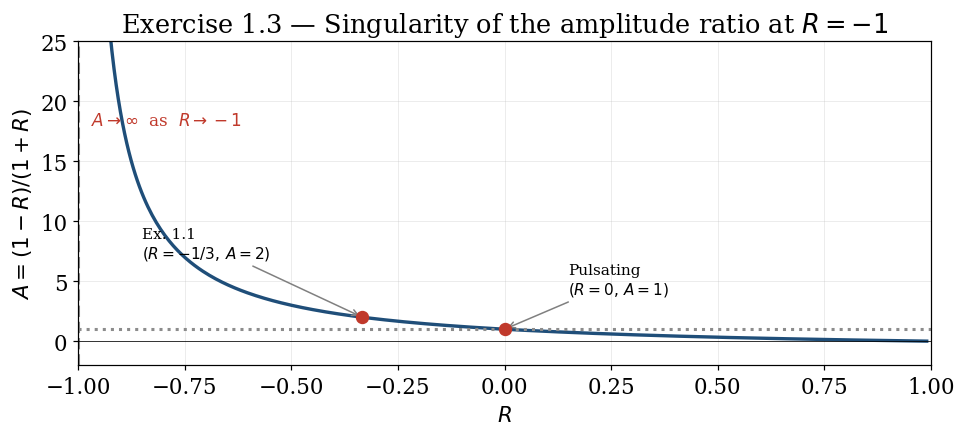

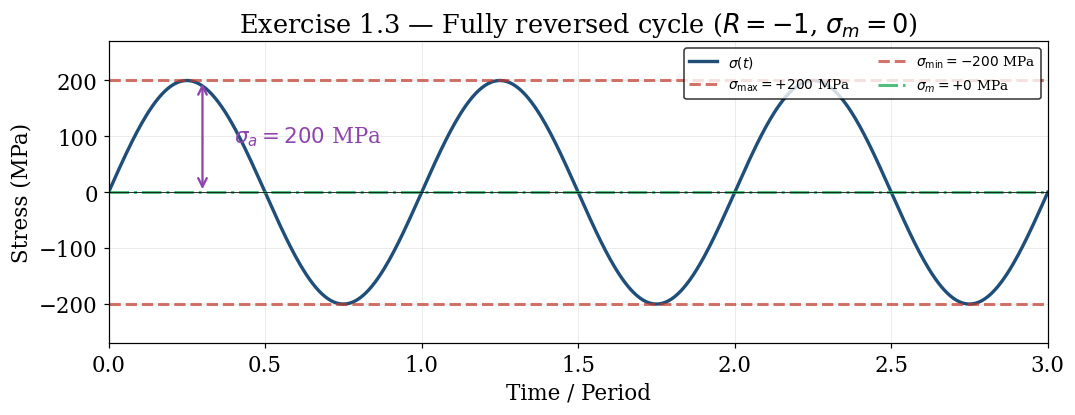

In [12]:
# Visualise the divergence A(R) → ∞ as R → −1
R_arr = np.linspace(-0.99, 0.99, 400)
A_arr = (1 - R_arr) / (1 + R_arr)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(R_arr, A_arr, color=COLORS['curve'], lw=2.2)
ax.axvline(-1, color=COLORS['guide'], ls='--')
ax.axhline( 1, color=COLORS['guide'], ls=':')
ax.axhline( 0, color='k', lw=0.5)
ax.scatter([0, -1/3], [1, 2], color=COLORS['point'], s=60, zorder=5)
ax.annotate('Pulsating\n$(R=0,\,A=1)$', xy=(0, 1),
            xytext=(0.15, 4), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Ex. 1.1\n$(R=-1/3,\,A=2)$', xy=(-1/3, 2),
            xytext=(-0.85, 7), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(-0.97, 18, r'$A\to\infty$  as  $R\to-1$',
        fontsize=11, color=COLORS['sig_max'])
ax.set_xlabel(r'$R$'); ax.set_ylabel(r'$A=(1-R)/(1+R)$')
ax.set_xlim(-1, 1); ax.set_ylim(-2, 25)
ax.set_title('Exercise 1.3 — Singularity of the amplitude ratio at $R=-1$')
plt.tight_layout(); plt.show()

plot_stress_signal(p3, title='Exercise 1.3 — Fully reversed cycle ($R=-1$, $\\sigma_m=0$)')
plt.show()


<a id='ex4'></a>
---

## Exercise 1.4 — General relations between cyclic stress parameters

Consider a constant-amplitude tensile stress cycle for which the stress ratio
$R$ and the mean stress $\sigma_m$ are known.

(a) Starting from the definitions of $\sigma_m$ and $R$, set up a system of two equations in the two unknowns $\sigma_{\max}$ and $\sigma_{\min}$. Solve the system to obtain:

$$
    \sigma_{\max} = \frac{2\,\sigma_m}{1+R}\,, \qquad \sigma_{\min} = \frac{2\,R\,\sigma_m}{1+R}\,.
    \tag{4.1}
$$

(b)) Derive the stress amplitude and stress range in terms of $\sigma_m$ and $R$:

$$
    \sigma_a = \frac{1-R}{1+R}\,\sigma_m\,, \qquad \Delta\sigma = \frac{2(1-R)}{1+R}\,\sigma_m\,.
    \tag{4.2}
$$

(c) Confirm that $A = \sigma_a/\sigma_m = (1-R)/(1+R)$, which is consistent with the earlier definition.

(d) Explain why, for $R = -1$, the parameters $\sigma_m$ and $R$ are not sufficient to define the loading cycle. How many distinct fully reversed cycles share the same $\sigma_m = 0$ and $R = -1$?

### Solution

#### (a) Symbolic derivation with `sympy`

The two definitions

\begin{equation*}
\sigma_m = \dfrac{\sigma_{\max}+\sigma_{\min}}{2},\qquad
R = \dfrac{\sigma_{\min}}{\sigma_{\max}}
\tag{4.3}\end{equation*}

form a linear system for $(\sigma_{\max},\sigma_{\min})$ once $(\sigma_m,R)$ are
given. We solve it symbolically and display the result inline.


In [13]:
# Symbolic derivation
sigma_max_s, sigma_min_s = sy.symbols('sigma_max sigma_min', real=True)
sigma_m_s, R_s           = sy.symbols('sigma_m R',           real=True)

eq1 = sy.Eq(sigma_m_s, (sigma_max_s + sigma_min_s) / 2)
eq2 = sy.Eq(R_s,        sigma_min_s / sigma_max_s)

sol = sy.solve([eq1, eq2], (sigma_max_s, sigma_min_s), dict=True)[0]
sigma_max_expr = sy.simplify(sol[sigma_max_s])
sigma_min_expr = sy.simplify(sol[sigma_min_s])

display(Latex(r'$\sigma_{\max} = '   + sy.latex(sigma_max_expr) + r'$'))
display(Latex(r'$\sigma_{\min} = '   + sy.latex(sigma_min_expr) + r'$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### (b) Stress amplitude and stress range

Substituting (4.1) into the definitions of $\sigma_a$ and $\Delta\sigma$:


In [14]:
sigma_a_expr     = sy.simplify((sigma_max_expr - sigma_min_expr) / 2)
delta_sigma_expr = sy.simplify( sigma_max_expr - sigma_min_expr )

display(Latex(r'$\sigma_a = '       + sy.latex(sigma_a_expr)     + r'$'))
display(Latex(r'$\Delta\sigma = '  + sy.latex(delta_sigma_expr) + r'$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### (c) Amplitude ratio

\begin{equation*}
A = \dfrac{\sigma_a}{\sigma_m}
  = \dfrac{1-R}{1+R}.
\tag{4.4}\end{equation*}


In [15]:
A_expr = sy.simplify(sigma_a_expr / sigma_m_s)
display(Latex(r'$A = ' + sy.latex(A_expr) + r'$'))


<IPython.core.display.Latex object>

#### (d) Why $(\sigma_m,R)$ fails at $R=-1$

The closed-form expressions in (4.1)–(4.2) all carry the factor $1/(1+R)$.
At $R=-1$ the denominator is zero while the numerator $(2\sigma_m)$ vanishes
*only if* $\sigma_m=0$. Hence $\sigma_m=0$ and $R=-1$ together are
**consistent** with **any** fully reversed cycle: there is one free parameter
left (the amplitude). Numerical illustration:


In [16]:
print('Three different fully reversed cycles, all sharing σ_m = 0 and R = −1:')
for sa in [50, 200, 500]:
    p = cyclic_params(sigma_max= sa, sigma_min=-sa)
    print(f'  σ_a = {sa:4d} MPa  →  σ_max={p["sigma_max"]:+5.0f}, σ_min={p["sigma_min"]:+5.0f}, '
          f'σ_m={p["sigma_m"]:+5.1f}, R={p["R"]:+5.1f}')


Three different fully reversed cycles, all sharing σ_m = 0 and R = −1:
  σ_a =   50 MPa  →  σ_max=  +50, σ_min=  -50, σ_m= +0.0, R= -1.0
  σ_a =  200 MPa  →  σ_max= +200, σ_min= -200, σ_m= +0.0, R= -1.0
  σ_a =  500 MPa  →  σ_max= +500, σ_min= -500, σ_m= +0.0, R= -1.0


<a id='ex5'></a>
---

## Exercise 1.5 — S–N curve of a structural steel (Basquin law)

Consider an S–N curve representative of the fatigue behaviour of a structural steel detail, extracted from Eurocode 3. In the finite-life region, the curve is described by the following power-law relation:

$$
\Delta\sigma^{\,m}\,N_f = C,
\tag{5.1}
$$

where $C$ is a constant. Assume $m=3$ and that $N_f=2\times10^6$ cycles when $\Delta\sigma=160$ MPa. This defines the detail category FAT 160.

(a) Compute the constant $C$.

(b) Rewrite the S–N relation in the Basquin form

$$
\frac{\Delta\sigma}{2} = \sigma_f'(2N_f)^b.
$$

Determine the fatigue strength coefficient $\sigma_f'$ and the fatigue strength exponent $b$.

*Hint:* Starting from $\Delta\sigma^m N_f=C$, solve for $\Delta\sigma$ as a function of $N_f$ and rearrange to match the Basquin form.

(c) Compute the fatigue life $N_f$ for a stress range $\Delta\sigma=160$ MPa.

(d) Compute the fatigue strength, i.e. the stress range $\Delta\sigma$, for a life of $N_f=1\times10^6$ cycles.

(e) The fatigue limit is defined as the stress range corresponding to a life of $5\times10^6$ cycles, using the Eurocode 3 criterion. Compute the fatigue limit $\Delta\sigma_D$.

(f) Consider an applied stress range of $\Delta\sigma=300$ MPa.

&nbsp;&nbsp;&nbsp;&nbsp;(i) Compute the fatigue life $N_f$.

&nbsp;&nbsp;&nbsp;&nbsp;(ii) Now reduce the stress range by 10% to $\Delta\sigma=270$ MPa and recompute the fatigue life.

&nbsp;&nbsp;&nbsp;&nbsp;(iii) Express the life increase as a percentage.

&nbsp;&nbsp;&nbsp;&nbsp;(iv) Comment on the non-linearity of the S–N relation: why does a modest reduction in stress range lead to a disproportionate increase in fatigue life?

### Solution


#### (a) Constant $C$

From (5.1) at the reference point $(N_{f,\text{ref}},\Delta\sigma_{\text{ref}})=(2\times10^6,160)$:

\begin{equation*}
C = \Delta\sigma_{\text{ref}}^{\,m}\,N_{f,\text{ref}}
  = 160^{3}\cdot 2\times10^{6}
  \approx 8.192\times 10^{12}~\text{MPa}^{3}.
\tag{5.2}\end{equation*}


In [17]:
m_SN          = 3
Dsigma_ref    = 160.0        # MPa
Nf_ref        = 2.0e6        # cycles
C_SN          = Dsigma_ref**m_SN * Nf_ref
print(f'(a) C = Δσ_ref^m · N_f,ref = {Dsigma_ref}^{m_SN} · {Nf_ref:.0e}')
print(f'    C = {C_SN:.4e} MPa^{m_SN}')


(a) C = Δσ_ref^m · N_f,ref = 160.0^3 · 2e+06
    C = 8.1920e+12 MPa^3


#### (b) Equivalent Basquin form

Starting from (5.1), solve for $\Delta\sigma$ as a function of $N_f$ and
rearrange:

\begin{equation*}
\Delta\sigma = (C/N_f)^{1/m}
\;\Longrightarrow\;
\dfrac{\Delta\sigma}{2}
   = \underbrace{\dfrac{C^{1/m}}{2^{\,1-1/m}}}_{\sigma_f'}\;(2N_f)^{-1/m}.
\tag{5.3}\end{equation*}

Identifying with $\dfrac{\Delta\sigma}{2}=\sigma_f'\,(2N_f)^{b}$,

\begin{equation*}
b = -\dfrac{1}{m} = -\dfrac{1}{3},\qquad
\sigma_f' = \dfrac{C^{1/m}}{2^{\,1-1/m}} = \dfrac{C^{1/3}}{2^{2/3}}.
\tag{5.4}\end{equation*}


In [18]:
b_basquin     = -1.0/m_SN
sigma_f_prime = C_SN**(1.0/m_SN) / 2.0**(1.0 - 1.0/m_SN)
print('(b) Basquin exponent:')
print(f'    b = -1/m = -1/{m_SN} = {b_basquin:+.4f}')
print()
print('    Basquin coefficient (sigma_f_prime):')
print(f"    C^(1/m)   = ({C_SN:.4e})^(1/{m_SN}) = {C_SN**(1.0/m_SN):.4f}")
print(f"    2^(1-1/m) = 2^({1.0-1.0/m_SN:.4f})   = {2.0**(1.0-1.0/m_SN):.4f}")
print(f"    sigma_f'  = C^(1/m) / 2^(1-1/m)")
print(f"              = {C_SN**(1.0/m_SN):.4f} / {2.0**(1.0-1.0/m_SN):.4f}")
print(f"              = {sigma_f_prime:.2f} MPa")
print()
# Sanity check: evaluate Basquin at the reference point
Nf_check = Nf_ref
sa_check = sigma_f_prime * (2*Nf_check)**b_basquin
Ds_check = 2*sa_check
twoN     = 2*Nf_check
print(f'    Sanity check at the reference point (N_f = {Nf_check:.0e} cycles):')
print(f'    (2N_f)^b = ({twoN:.2e})^({b_basquin:+.4f}) = {twoN**b_basquin:.6f}')
print(f"    sigma_a  = sigma_f' * (2N_f)^b")
print(f"             = {sigma_f_prime:.2f} x {twoN**b_basquin:.6f} = {sa_check:.2f} MPa")
print(f'    Delta_sigma = 2*sigma_a = {Ds_check:.1f} MPa  (target: {Dsigma_ref:.1f} MPa)  ok')


(b) Basquin exponent:
    b = -1/m = -1/3 = -0.3333

    Basquin coefficient (sigma_f_prime):
    C^(1/m)   = (8.1920e+12)^(1/3) = 20158.7368
    2^(1-1/m) = 2^(0.6667)   = 1.5874
    sigma_f'  = C^(1/m) / 2^(1-1/m)
              = 20158.7368 / 1.5874
              = 12699.21 MPa

    Sanity check at the reference point (N_f = 2e+06 cycles):
    (2N_f)^b = (4.00e+06)^(-0.3333) = 0.006300
    sigma_a  = sigma_f' * (2N_f)^b
             = 12699.21 x 0.006300 = 80.00 MPa
    Delta_sigma = 2*sigma_a = 160.0 MPa  (target: 160.0 MPa)  ok


#### (c) Fatigue life at $\Delta\sigma=160$ MPa

\begin{equation*}
N_f = \dfrac{C}{\Delta\sigma^{\,m}}
    = \dfrac{8.192\times 10^{12}}{160^{3}}
    = 2\times10^{6}~\text{cycles},
\tag{5.5}\end{equation*}

confirming the reference point.


In [19]:
Dsigma_c  = 160.0
Dsigma_cm = Dsigma_c**m_SN
Nf_c      = C_SN / Dsigma_cm
print('(c) N_f = C / Delta_sigma^m')
print(f'       = {C_SN:.4e} / ({Dsigma_c:.0f})^{m_SN}')
print(f'       = {C_SN:.4e} / {Dsigma_cm:.4e}')
print(f'       = {Nf_c:.3e} cycles  (confirms the reference point)')


(c) N_f = C / Delta_sigma^m
       = 8.1920e+12 / (160)^3
       = 8.1920e+12 / 4.0960e+06
       = 2.000e+06 cycles  (confirms the reference point)


#### (d) Fatigue strength at $N_f=1\times10^{6}$ cycles

\begin{equation*}
\Delta\sigma(N_f) = (C/N_f)^{1/m}
\;\Longrightarrow\;
\Delta\sigma(10^{6}) \approx 201.6~\text{MPa}.
\tag{5.6}\end{equation*}


In [20]:
Nf_d        = 1.0e6
C_over_Nf_d = C_SN / Nf_d
Dsigma_d    = C_over_Nf_d**(1.0/m_SN)
print('(d) Delta_sigma = (C / N_f)^(1/m)')
print(f'               = ({C_SN:.4e} / {Nf_d:.0e})^(1/{m_SN})')
print(f'               = ({C_over_Nf_d:.4e})^({1.0/m_SN:.4f})')
print(f'               = {Dsigma_d:.2f} MPa')


(d) Delta_sigma = (C / N_f)^(1/m)
               = (8.1920e+12 / 1e+06)^(1/3)
               = (8.1920e+06)^(0.3333)
               = 201.59 MPa


#### (e) Fatigue limit (EC3 criterion: $N_f=5\times10^{6}$)

\begin{equation*}
\Delta\sigma_D = (C/5\times10^{6})^{1/3} \approx 117.9~\text{MPa}.
\tag{5.7}\end{equation*}


In [21]:
Nf_e        = 5.0e6
C_over_Nf_e = C_SN / Nf_e
Dsigma_D    = C_over_Nf_e**(1.0/m_SN)
print(f'(e) Delta_sigma_D = (C / N_f)^(1/m)  with N_f = {Nf_e:.0e} cycles  (EC3 criterion)')
print(f'                  = ({C_SN:.4e} / {Nf_e:.0e})^(1/{m_SN})')
print(f'                  = ({C_over_Nf_e:.4e})^({1.0/m_SN:.4f})')
print(f'                  = {Dsigma_D:.2f} MPa  <-  fatigue limit Delta_sigma_D')


(e) Delta_sigma_D = (C / N_f)^(1/m)  with N_f = 5e+06 cycles  (EC3 criterion)
                  = (8.1920e+12 / 5e+06)^(1/3)
                  = (1.6384e+06)^(0.3333)
                  = 117.89 MPa  <-  fatigue limit Delta_sigma_D


#### (f) Sensitivity to a 10% stress-range reduction

For the applied stress range $\Delta\sigma_1=300$ MPa,

$$
N_{f,1}=\frac{C}{\Delta\sigma_1^m}.
\tag{5.8}
$$

After reducing the stress range by 10%, $\Delta\sigma_2=270$ MPa, and

$$
N_{f,2}=\frac{C}{\Delta\sigma_2^m}.
\tag{5.9}
$$

The percentage life increase is therefore

$$
\frac{N_{f,2}-N_{f,1}}{N_{f,1}}\times100.
\tag{5.10}
$$

Because $N_f\propto\Delta\sigma^{-m}$, the life ratio can also be obtained directly as

$$
\frac{N_{f,2}}{N_{f,1}}
=
\left(\frac{\Delta\sigma_1}{\Delta\sigma_2}\right)^m
=
\left(\frac{300}{270}\right)^3
=
(1/0.9)^3
\approx 1.372.
\tag{5.11}
$$

Thus, a 10% reduction in stress range produces an approximately 37% increase in life. This illustrates the strong non-linearity of the S–N relation: fatigue life varies with the inverse power of the stress range, here with exponent $m=3$.


In [22]:
Dsigma_f1, Dsigma_f2 = 300.0, 270.0
Nf_f1 = C_SN / Dsigma_f1**m_SN
Nf_f2 = C_SN / Dsigma_f2**m_SN
incr  = (Nf_f2/Nf_f1 - 1.0)*100

print(f'(f-i)   Delta_sigma_1 = {Dsigma_f1:.0f} MPa')
print(f'        Delta_sigma_1^m = ({Dsigma_f1:.0f})^{m_SN} = {Dsigma_f1**m_SN:.4e} MPa^{m_SN}')
print(f'        N_f,1 = C / Delta_sigma_1^m')
print(f'              = {C_SN:.4e} / {Dsigma_f1**m_SN:.4e}')
print(f'              = {Nf_f1:.3e} cycles')
print()
print(f'(f-ii)  Delta_sigma_2 = {Dsigma_f2:.0f} MPa  (= 0.9 x {Dsigma_f1:.0f})')
print(f'        Delta_sigma_2^m = ({Dsigma_f2:.0f})^{m_SN} = {Dsigma_f2**m_SN:.4e} MPa^{m_SN}')
print(f'        N_f,2 = C / Delta_sigma_2^m')
print(f'              = {C_SN:.4e} / {Dsigma_f2**m_SN:.4e}')
print(f'              = {Nf_f2:.3e} cycles')
print()
print('(f-iii) Life increase = (N_f,2 / N_f,1 - 1) x 100')
print(f'              = ({Nf_f2:.3e} / {Nf_f1:.3e} - 1) x 100')
print(f'              = ({Nf_f2/Nf_f1:.4f} - 1) x 100')
print(f'              = {incr:+.1f} %')
print('        Check via power-law ratio:')
print(f'        (Delta_sigma_1 / Delta_sigma_2)^m - 1')
print(f'              = ({Dsigma_f1:.0f} / {Dsigma_f2:.0f})^{m_SN} - 1')
print(f'              = ({Dsigma_f1/Dsigma_f2:.4f})^{m_SN} - 1')
print(f'              = {(Dsigma_f1/Dsigma_f2)**m_SN:.4f} - 1 = {(Dsigma_f1/Dsigma_f2)**m_SN-1:+.4f}  ok')


(f-i)   Delta_sigma_1 = 300 MPa
        Delta_sigma_1^m = (300)^3 = 2.7000e+07 MPa^3
        N_f,1 = C / Delta_sigma_1^m
              = 8.1920e+12 / 2.7000e+07
              = 3.034e+05 cycles

(f-ii)  Delta_sigma_2 = 270 MPa  (= 0.9 x 300)
        Delta_sigma_2^m = (270)^3 = 1.9683e+07 MPa^3
        N_f,2 = C / Delta_sigma_2^m
              = 8.1920e+12 / 1.9683e+07
              = 4.162e+05 cycles

(f-iii) Life increase = (N_f,2 / N_f,1 - 1) x 100
              = (4.162e+05 / 3.034e+05 - 1) x 100
              = (1.3717 - 1) x 100
              = +37.2 %
        Check via power-law ratio:
        (Delta_sigma_1 / Delta_sigma_2)^m - 1
              = (300 / 270)^3 - 1
              = (1.1111)^3 - 1
              = 1.3717 - 1 = +0.3717  ok


#### Plot the S–N curve

On log–log axes the power law (5.1) becomes a **straight line of slope
$-1/m=-1/3$**. We overlay the reference point, the requested operating
points (c)–(f), and the EC3 fatigue limit $\Delta\sigma_D$.


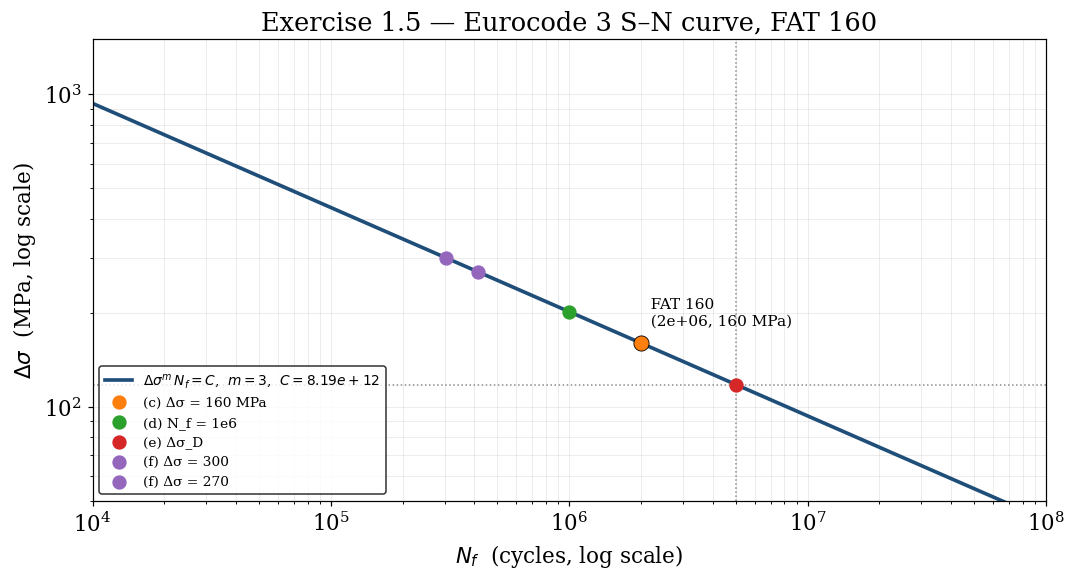

In [23]:
# S–N curve on log–log axes
Nf_plot     = np.logspace(4, 8, 400)
Dsigma_plot = (C_SN / Nf_plot)**(1.0/m_SN)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.loglog(Nf_plot, Dsigma_plot, color=COLORS['curve'], lw=2.4,
          label=fr'$\Delta\sigma^{{m}}\,N_f = C$,  $m={m_SN}$,  $C={C_SN:.2e}$')

# Reference point
ax.scatter(Nf_ref, Dsigma_ref, s=90, color='black', zorder=5)
ax.annotate(f'  FAT 160\n  ({Nf_ref:.0e}, {Dsigma_ref:.0f} MPa)',
            xy=(Nf_ref, Dsigma_ref), xytext=(0, 12), textcoords='offset points',
            fontsize=10)

# Operating points
for label, Nf_i, Ds_i, col in [
        ('(c) Δσ = 160 MPa', Nf_c,  Dsigma_c,  'tab:orange'),
        ('(d) N_f = 1e6',    Nf_d,  Dsigma_d,  'tab:green'),
        ('(e) Δσ_D',         Nf_e,  Dsigma_D,  'tab:red'),
        ('(f) Δσ = 300',     Nf_f1, Dsigma_f1, 'tab:purple'),
        ('(f) Δσ = 270',     Nf_f2, Dsigma_f2, 'tab:purple'),
]:
    ax.scatter(Nf_i, Ds_i, s=70, color=col, zorder=5, label=label)

# EC3 endurance line
ax.axvline(Nf_e,     color=COLORS['guide'], ls=':', lw=1)
ax.axhline(Dsigma_D, color=COLORS['guide'], ls=':', lw=1)

ax.set_xlabel(r'$N_f$  (cycles, log scale)')
ax.set_ylabel(r'$\Delta\sigma$  (MPa, log scale)')
ax.set_title('Exercise 1.5 — Eurocode 3 S–N curve, FAT 160')
ax.set_xlim(1e4, 1e8); ax.set_ylim(50, 1500)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()


#### Solution summary — Exercise 1.5

| Part | Quantity | Value |
|:----:|:---------|------:|
| (a)  | $C$ | $8.192\times10^{12}$ MPa$^3$ |
| (b)  | $b=-1/m$ | $-1/3$ |
| (b)  | $\sigma_f'$ | $\approx 1.27\times10^{4}$ MPa |
| (c)  | $N_f(\Delta\sigma=160$ MPa$)$ | $2.0\times10^{6}$ cycles |
| (d)  | $\Delta\sigma(N_f=10^{6})$ | $\approx 201.6$ MPa |
| (e)  | $\Delta\sigma_D$ at $5\times10^{6}$ cycles | $\approx 117.9$ MPa |
| (f-i) | $N_f(\Delta\sigma=300$ MPa$)$ | $\approx 3.034\times10^{5}$ cycles |
| (f-ii) | $N_f(\Delta\sigma=270$ MPa$)$ | $\approx 4.162\times10^{5}$ cycles |
| (f-iii) | Life increase for $-10$% stress range | $\approx 37.2$% |
| (f-iv) | Interpretation | $N_f\propto\Delta\sigma^{-3}$, so life is highly sensitive to stress range. |

---


<a id='ex6'></a>
---

## Exercise 1.6 — Conceptual questions on fatigue fundamentals

The following questions are drawn from **Schijve, *Fatigue of Structures and Materials*, Ch. 2**.
They are discussed in class and do not require numerical calculations.

#### Problem statement

The following conceptual questions are drawn from Schijve (2009), Chapter 2.
They should be discussed in class and do not require numerical calculations.

(a) The fatigue life of a component is conventionally divided into three phases:
crack initiation, crack growth, and final failure.

- Which factors are significant for each of these three phases?
- What is the most essential feature of the crack initiation period?
- What is an important difference between the crack initiation and crack growth periods?
- What is an important material characteristic governing the crack growth period?

(b) Give two different definitions of the fatigue limit $S_f$. Under what circumstances
may the fatigue limit not exist as a well-defined horizontal asymptote of the S--N curve?

(c) What is the difference between high-cycle fatigue (HCF) and low-cycle fatigue (LCF)?

(d) An S--N curve has an upper and a lower horizontal asymptote. Explain the physical
meaning of each.

(e) On a double-logarithmic scale, an S--N curve often exhibits a large linear part.
Which equation describes this part, and what are the roles of its constants?

(f) The fatigue limit for $S_m=0$ within a particular alloy family is often found to be
linearly related to the ultimate tensile strength of the material. This implies that a
stronger material should have a higher fatigue limit.

- Is this a useful trend for material selection? Discuss limitations.
- The linear relation between $S_f$ and $S_u$ for steels is sometimes not maintained for
  very high-strength steels. Explain why.

### Solution

**(a) Three phases of fatigue life.** Crack initiation, crack growth, final failure.

| Phase | Driving factor | Most relevant variable |
|:------|:---|:---|
| Initiation | local plasticity at the most stressed surface point | $K_t$, surface finish, residual stress |
| Crack growth | range of the singular field at the tip | $\Delta K$, environment, $R$-ratio |
| Final failure | when $K_{\max}=K_c$ or net section yields | $K_c$, $\sigma_y$, geometry |

*Essence of initiation*: it is **surface-controlled** — driven by cyclic
microplasticity at slip bands intersecting the free surface.

*Initiation vs. growth*: in initiation the crack does not yet exist, so the
$K_t$ field rules; in growth the crack tip has its own singular field
characterised by $K$ (Schijve Ch. 5). Initiation is dominated by **surface
quality**, growth is dominated by **bulk fracture toughness and environment**.

*Material parameter for growth*: the crack-growth-rate law parameters
$C,m$ in $\mathrm{d}a/\mathrm{d}N = C(\Delta K)^{m}$ (Paris law).

**(b) Fatigue limit $S_f$.** Two operational definitions:

1. The stress amplitude at which the S–N curve becomes a horizontal asymptote.
2. The stress amplitude at which the specimen survives a conventionally large
   number of cycles ($10^{7}$ for steel, often $5\times10^{8}$ for aluminium).

A *true* horizontal asymptote may **not exist** for many alloys (most
aluminium and titanium alloys, austenitic stainless steels, all alloys in a
corrosive environment); the S–N curve then keeps sloping down indefinitely
and one has to fall back to definition 2.

**(c) HCF vs. LCF.**

| | HCF | LCF |
|:---|:---|:---|
| Cycle count | $N>10^{4}$–$10^{5}$ | $N<10^{4}$ |
| Strain | mostly elastic | substantial plastic |
| Design law | stress-life (Basquin) | strain-life (Coffin–Manson) |
| Example | bridge details, aero structures | turbine start-up cycles |

**(d) Upper and lower asymptotes of the S–N curve.**

The **upper asymptote** is the static strength: a single half-cycle to the
ultimate tensile strength $\sigma_u$ fails the specimen at $N=\tfrac14$
cycle. The **lower asymptote** is the fatigue limit $S_f$ (when it exists):
below this stress amplitude, the specimen will not fail by fatigue alone.

**(e) Linear part on log–log scale.** Described by Basquin,
$\sigma_a=\sigma_f'(2N_f)^{b}$. On $\log\sigma_a$–$\log N_f$ axes the slope
is $b$ and the intercept (at $2N_f=1$) is $\sigma_f'$. They have a clear
mechanical reading: $\sigma_f'$ is an extrapolation of the true fracture
stress at one reversal, and $b$ is a measure of the material's
fatigue-resistance "rate".

**(f) Fatigue limit vs. ultimate strength.**

(i) For ferrous alloys at modest strength the empirical relation
$S_f\approx 0.5\,\sigma_u$ is a *very* useful screening tool — higher-strength
steels give higher fatigue limits, **as long as** surface finish and
microstructure are comparable.

(ii) The trend **breaks down** for very high-strength steels (typically
$\sigma_u>1400$ MPa). High strength is usually achieved by tempering at low
temperatures, which leaves a coarse martensitic structure with low ductility
and high notch sensitivity; small surface defects or inclusions then govern
the fatigue strength, and $S_f/\sigma_u$ saturates or even decreases.


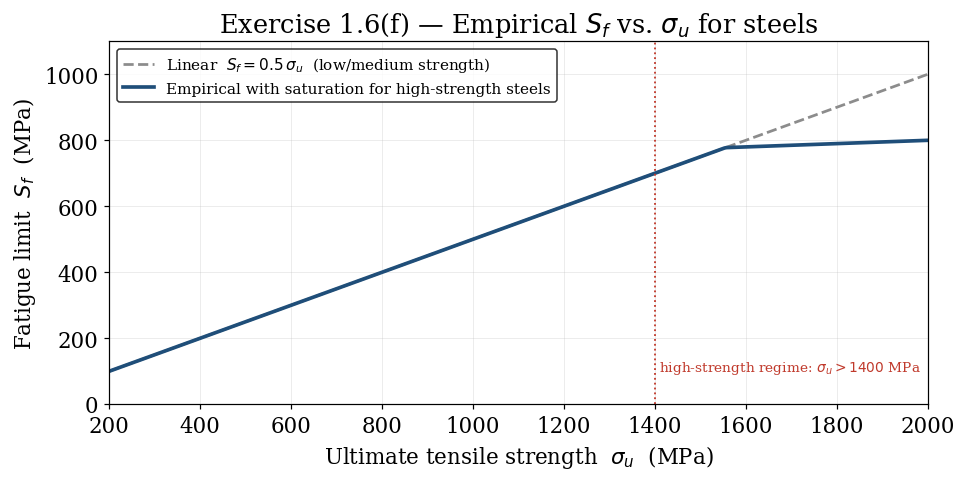

In [24]:
# Illustrative plot: empirical S_f vs. S_u trend for steels
Su = np.linspace(200, 2000, 400)
Sf_linear      = 0.5 * Su                              # naive linear
Sf_saturation  = np.minimum(0.5*Su, 700.0 + 0.05*Su)   # crude saturation cap

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Su, Sf_linear,     '--', color=COLORS['guide'], lw=1.8,
        label=r'Linear  $S_f = 0.5\,\sigma_u$  (low/medium strength)')
ax.plot(Su, Sf_saturation, '-',  color=COLORS['curve'], lw=2.4,
        label=r'Empirical with saturation for high-strength steels')
ax.axvline(1400, color=COLORS['sig_max'], ls=':', lw=1.2)
ax.text(1410, 100, r'high-strength regime: $\sigma_u>1400$ MPa',
        color=COLORS['sig_max'], fontsize=9)
ax.set_xlabel(r'Ultimate tensile strength  $\sigma_u$  (MPa)')
ax.set_ylabel(r'Fatigue limit  $S_f$  (MPa)')
ax.set_title('Exercise 1.6(f) — Empirical $S_f$ vs. $\\sigma_u$ for steels')
ax.set_xlim(200, 2000); ax.set_ylim(0, 1100)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.show()


---

### Final remarks

* All numerical results follow exclusively from the formulary at the top of the
  notebook. No fitting or empirical correction is invoked beyond the assumed
  S–N exponent $m=3$ (EC3, detail-category FAT 160).
* The power-law nature of (5.1) is the single most important property of
  S–N design: small reductions in stress range translate into large gains in
  service life, but conversely a small overload severely shortens it.
* For $R$-ratios different from those covered here (mean-stress effects), see
  *Problems 2* (Goodman / Gerber / Soderberg) and *Problems 3* (variable
  amplitude, Miner's rule).


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.